### Email Spam Classification Using Extra Trees Algorithm

# Student Information :
#### Name: Muhammad Sajawal  
#### Roll Number: 1687    
#### College: Government Abdul Ali Khan College Utmanzai
#### Email : sajosajawal9@gmail.com
#### supervised By Sakin Jan
# Project Objective:
The objective of this project is to develop a machine learning model that can automatically classify emails as Spam or Ham (Not Spam). The model uses the Extra Trees Classifier to learn patterns from email text and accurately identify unwanted emails.

# Dataset Description:
The dataset contains email messages labeled as Spam or Ham. Each email message is processed and converted into numerical features using TF-IDF (Term Frequency–Inverse Document Frequency) for machine learning analysis.

# Machine Learning Algorithm(s) Used :
TF-IDF Vectorization
Extra Trees Classifier

# Required Libraries:
pandas
numpy
matplotlib
seaborn
scikit-learn

# Instructions to Run the Project:
#### 1 Open the Jupyter Notebook (.ipynb file).
#### 2 Install the required libraries.
#### 3 Load the dataset.
#### 4 Preprocess and clean the email text.
#### 5 Convert text data into numerical features using TF-IDF.
#### 6 Split the dataset into training and testing sets.
#### 7 Train the Extra Trees Classifier model.
#### 8  Evaluate the model performance.
#### 9  View the generated results and visualizations.



In [26]:
# data handling libraries
import pandas as pd   # handle tabuler data like csv/Execel and create dataframe and series
import numpy as np    # for numeric operation + array 
# Visuallization libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer # convert text data into numbers that ML model cen understand.
from sklearn.ensemble import ExtraTreesClassifier # A classification algorithm . predict spam vs ham.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # To evalute model performance

In [2]:
# laod dataset 
dataset = pd.read_csv("spam dataset.csv", encoding='latin-1')

In [3]:
dataset.head() # show first 5 rows .

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
# keep only requried columns
# remove Extra columns and keeps only Label and message columns .
df = dataset[['v1' , 'v2']]
df.columns = ['label', 'message']
df

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
# convert label into Numbers
df['label'] = df['label'].map({
    'ham': 0 , 
    'spam' : 1
})

In [6]:
df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


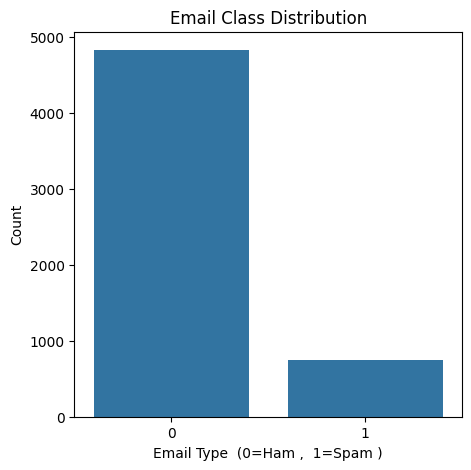

In [7]:
# this shows how many emails are spam and how many are ham
plt.figure(figsize=(5,5))
sns.countplot(x='label' , data=df)
plt.title('Email Class Distribution')
plt.xlabel('Email Type  (0=Ham ,  1=Spam )')
plt.ylabel('Count')
plt.show()

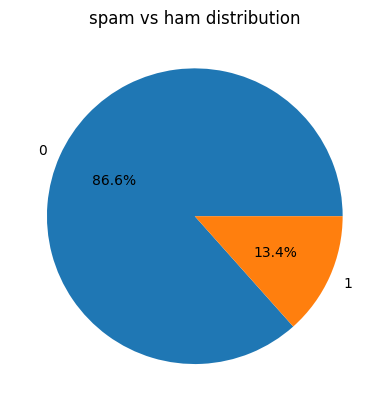

In [8]:
# its also shows distribution of spam and ham emails .
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%',)
plt.title('spam vs ham distribution')
plt.ylabel('')
plt.show()

In [9]:
#  Separate features and target
X = df['message']
Y = df['label']

In [10]:
X = df['message']
# X = email/SMS text.
print(X.head()) # it shows only messages .

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: message, dtype: str


In [11]:
Y = df['label']
# Y = spam or not spam
print(Y.head()) # it shows only spam and ham .
                # 0 for ham and 1 for spam .

0    0
1    0
2    1
3    0
4    0
Name: label, dtype: int64


In [12]:
#convert text into numerical features using TF - IDF
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X)

In [13]:
#  TF - IDF convert words into numbers
print (X.shape) # Means that 5572 (Messages) and 8404 ( Unique word ).

(5572, 8404)


In [14]:
# split dataset 
X_train, X_test, y_train, y_test = train_test_split ( 
    X ,
    Y , 
    test_size = 0.2 , # 20 % Testing Data 
    random_state=42   # 80 % Training Data
)

In [15]:
print(X_train.shape)
print(X_test.shape)

(4457, 8404)
(1115, 8404)


In [16]:
# create Extra Trees Model
model = ExtraTreesClassifier(          # Create 100 decision trees . 
    n_estimators = 100,             # Uses random feature selection.
    random_state = 42                 # Final prediction is based on majority voting . No output.
)

In [17]:
# train model                 #Model learn patterns from training data.
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [18]:
# Make prediction # predict spam and ham for unseen massages
y_pred = model.predict(X_test)
print(y_pred[:15])

[0 0 1 0 1 0 0 0 0 0 0 1 0 0 0]


In [19]:
# Accuraccy  # Measures percentage of correct predictions.
accuracy = accuracy_score(y_test, y_pred)
print("Accuuuracy" , accuracy)

Accuuuracy 0.9757847533632287


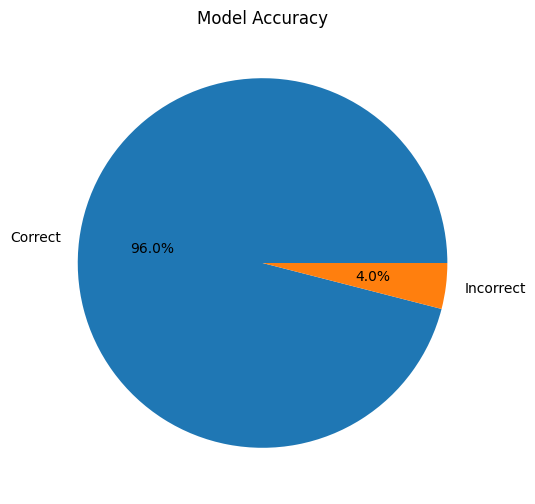

In [20]:
# pie chart for accuracy
accuracy = 96 
error = 100 - accuracy 
plt.figure(figsize=(6,6))
plt.pie([accuracy,error],                            
labels=['Correct','Incorrect'],
autopct='%1.1f%%'  )                  
plt.title('Model Accuracy')
plt.show()

In [21]:
# Confusion Matrix
print ("Confusion Matrix")
print(confusion_matrix(y_test, y_pred)) 
#             Predicted Ham        Predicted Spam 
# Actual Ham         961                    4
# Actual Spam        23                  127

Confusion Matrix
[[961   4]
 [ 23 127]]


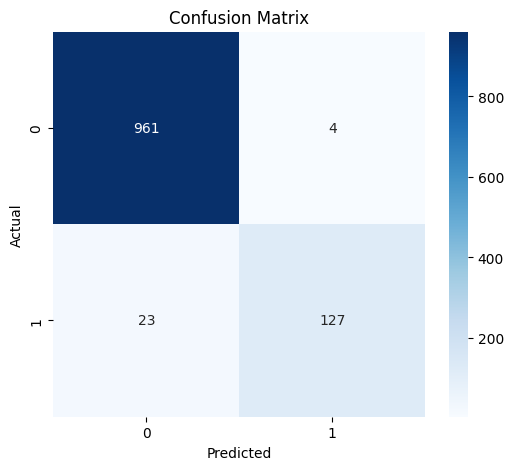

In [22]:
# confusion matrix visualization .
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot = True,
            fmt = 'd',
            cmap = 'Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
# Claaification Report
print (classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.97      0.85      0.90       150

    accuracy                           0.98      1115
   macro avg       0.97      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [24]:
# Test Custom or New Email 
email = [ " Congratulation You have won  a $1000 . Click here to claim your prize "]
email_vector = vectorizer.transform(email)
prediction = model.predict(email_vector)
if prediction[0] == 1:
    print("spam email")
else:
    print("Not spam email")
print(prediction)        # 1  = spam
                         # 0  = ham 

spam email
[1]


In [25]:
# final Expected Result
# dataset size : 5557
# Training data : 4457
# Testing Data : 1115
# Accuracy : 97 -- 99 %
# Spam Detection: Very High Accuracy